In [6]:
import yfinance as yf

data = yf.download("AAPL", start="2020-01-01", end="2026-05-12")
data.to_csv("AAPL_stock_data.csv")

[*********************100%***********************]  1 of 1 completed


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from statsmodels.formula.api import ols
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.signal import periodogram

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [28]:
df = pd.read_csv('AAPL_stock_data.csv')
df = df.drop(index = [0,1])
df.rename(columns={'Price': 'Date'}, inplace=True)
df.set_index('Date', inplace=True)
df = df.apply(pd.to_numeric)
df = df.round(5)
df.index = pd.to_datetime(df.index)
df

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.33387,72.39408,71.09118,71.34405,135480400
2020-01-03,71.63065,72.38927,71.40668,71.56322,146322800
2020-01-06,72.20139,72.23992,70.50352,70.75399,118387200
2020-01-07,71.86185,72.46633,71.64269,72.21105,108872000
2020-01-08,73.01785,73.31889,71.56563,71.56563,132079200
...,...,...,...,...,...
2026-05-05,283.91843,284.30808,276.24550,276.67510,49311700
2026-05-06,287.24536,287.76487,280.81129,281.66051,58336100
2026-05-07,287.17542,291.86110,285.51694,289.00372,45224300


In [29]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [30]:
df.describe()

,Close,High,Low,Open,Volume
count,1597.000000,1597.000000,1597.000000,1597.000000,1.597000e+03
mean,170.118561,171.861094,168.214589,169.961891,8.246288e+07
std,53.303032,53.665840,52.903833,53.268447,5.076540e+07
min,54.163700,55.160700,51.324800,55.059310,1.791060e+07
25%,133.226990,135.352760,131.891520,133.151130,4.931170e+07
50%,167.321670,168.915660,165.802310,167.321680,6.844560e+07
75%,210.435170,212.556750,208.094440,210.116430,9.791850e+07
max,293.050020,294.488700,290.230010,291.980010,4.265100e+08


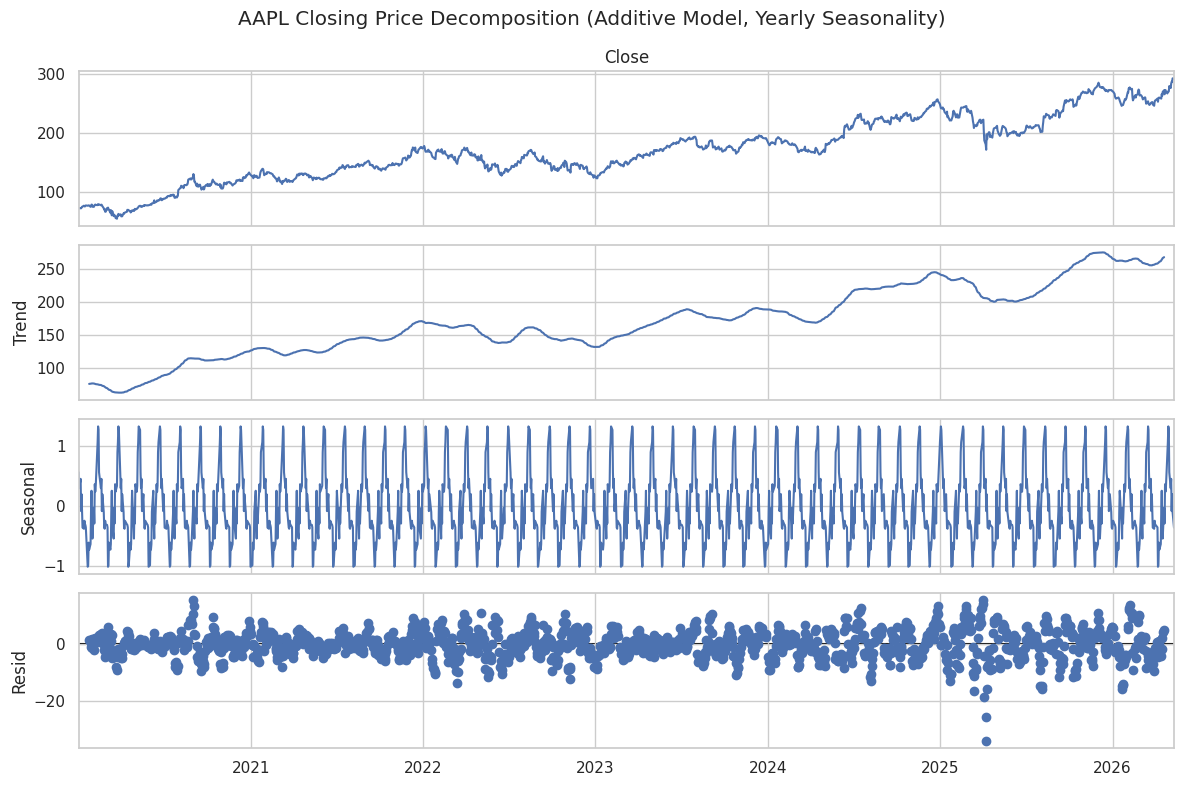

In [31]:
####   to double check ####

result = seasonal_decompose(df['Close'], model='additive', period=30) 
fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('AAPL Closing Price Decomposition (Additive Model, Yearly Seasonality)')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))  
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

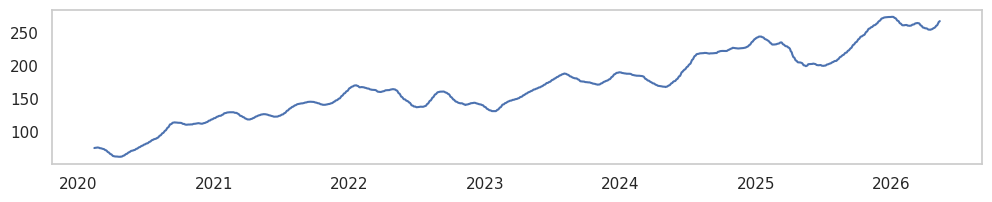

In [43]:
moving_avg =  df['Close'].rolling(window = 30).mean()
df.index = pd.to_datetime(df.index)
plt.figure(figsize=(12, 2))
plt.plot(df.index, moving_avg)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))  
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(False)
plt.show()

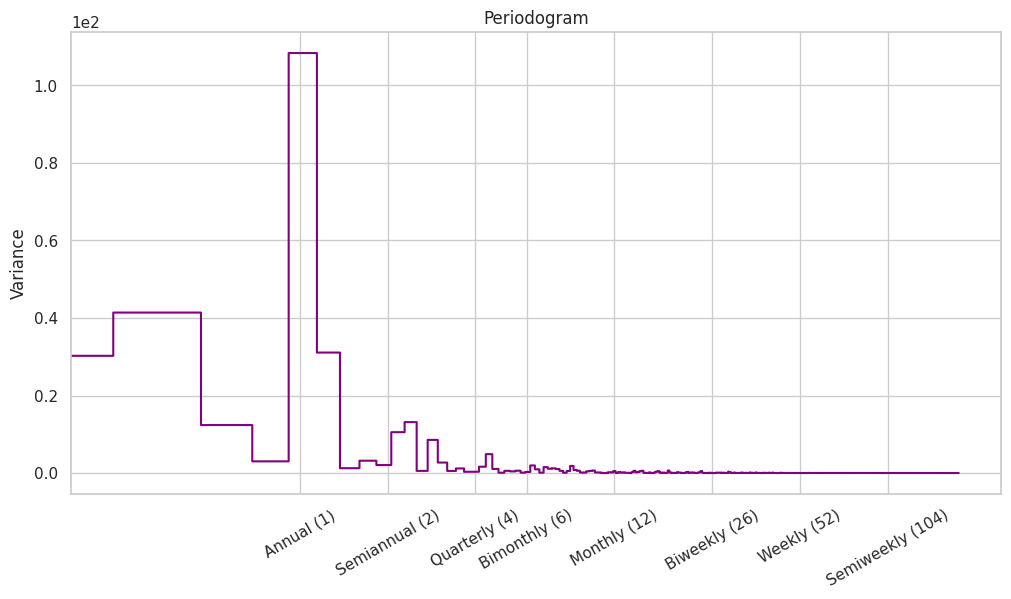

In [13]:
fs = pd.Timedelta("365D") / pd.Timedelta("1D")
frequencies, spectrum = periodogram(
    df['Close'],
    fs=fs,
    detrend='linear',
    window="boxcar",
    scaling='spectrum',
)

plt.figure(figsize=(12, 6))
plt.step(frequencies, spectrum, color="purple")
plt.xscale("log")
plt.xticks([1, 2, 4, 6, 12, 26, 52, 104])
plt.xticks(
    [1, 2, 4, 6, 12, 26, 52, 104],
    [
        "Annual (1)",
        "Semiannual (2)",
        "Quarterly (4)",
        "Bimonthly (6)",
        "Monthly (12)",
        "Biweekly (26)",
        "Weekly (52)",
        "Semiweekly (104)",
    ],
    rotation=30,
)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.ylabel("Variance")
plt.title("Periodogram")
plt.grid(True)
plt.show()


In [56]:
df = df.asfreq('D')
df['Close'] = df['Close'].interpolate()

In [62]:
fourier = CalendarFourier(freq="YE", order=2)
df.index = pd.to_datetime(df.index)
dp = DeterministicProcess(
    index= df['Close'].index,
    period = 252,
    constant=True,             
    seasonal=True,               
    additional_terms=[fourier], 
    drop=True,
)

X = dp.in_sample()
X

,const,"s(2,252)","s(3,252)","s(4,252)","s(5,252)","s(6,252)","s(7,252)","s(8,252)","s(9,252)","s(10,252)",...,"s(247,252)","s(248,252)","s(249,252)","s(250,252)","s(251,252)","s(252,252)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)"
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.017166,0.999853,0.034328,0.999411
2020-01-03,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.034328,0.999411,0.068615,0.997643
2020-01-04,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.051479,0.998674,0.102821,0.994700
2020-01-05,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.068615,0.997643,0.136906,0.990584
2020-01-06,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.085731,0.996318,0.170830,0.985301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-07,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.826354,-0.563151,-0.930724,-0.365723
2026-05-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.816538,-0.577292,-0.942761,-0.333469
2026-05-09,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.806480,-0.591261,-0.953681,-0.300820


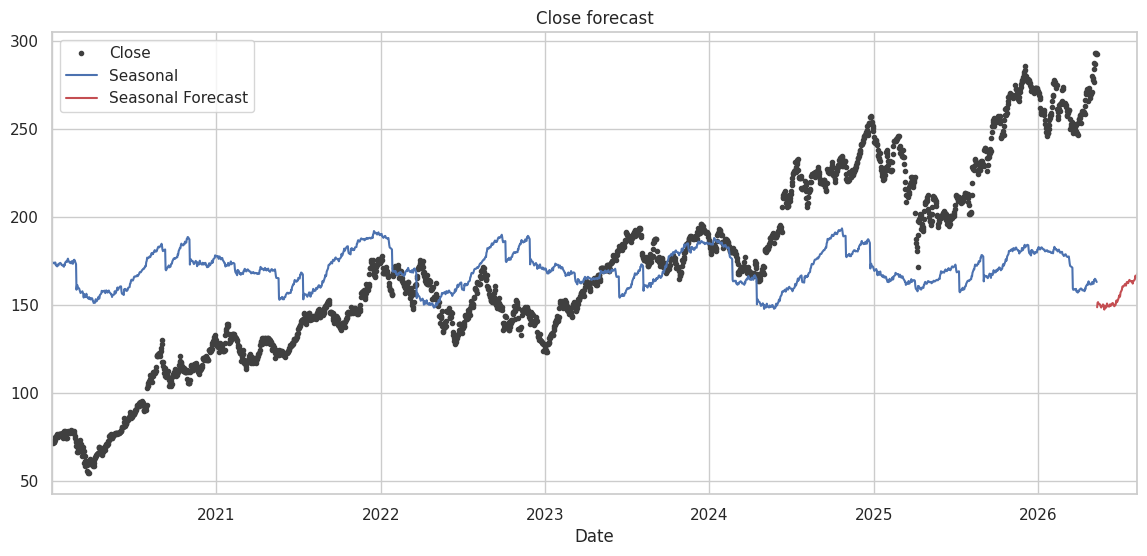

In [64]:
y = df["Close"]
model = LinearRegression(fit_intercept=False)
_ = model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=y.index)
X_fore = dp.out_of_sample(steps=90)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(color='0.25', style='.', title="Close forecast")
ax = y_pred.plot(ax=ax, label="Seasonal")
ax = y_fore.plot(ax=ax, label="Seasonal Forecast", color='C3')
_ = ax.legend()